# Gradyan İnişi

Bu egzersizde, tek bir Gradyan İnişi Epoch'unun adımlarını gerçekleştirmek için gerekli fonksiyonları oluşturacaksınız. Daha sonra fonksiyonları birleştirecek ve tüm Gradyan İnişi prosedürü boyunca bir döngü oluşturacaksınız.

## 1. Veri Keşfi

Sizin için mineral içerikleri olan malzemelerin aşağıdaki veri setini içe aktaracağız

In [1]:
import pandas as pd

data = pd.read_csv("https://d32aokrjazspmn.cloudfront.net/materials/gradient_descent_ingredients_zinc_phosphorous.csv")
data.head()

,aliment,zinc,phosphorus
0,Durum wheat pre-cooked. whole grain. cooked. u...,0.120907,0.193784
1,Asian noodles. plain. cooked. unsalted,0.047859,0.060329
2,Rice. brown. cooked. unsalted,0.156171,0.201097
3,Rice. cooked. unsalted,0.065491,0.045704
4,Rice. parboiled. cooked. unsalted,0.025189,0.045704


👇 `Fosfor` ve `Çinko` arasında bir nebze Doğrusal bir ilişkiyi görselleştirebiliriz.   

Aralarında en uygun çizgiyi bulmak için Gradyan İnişi kullanalım!

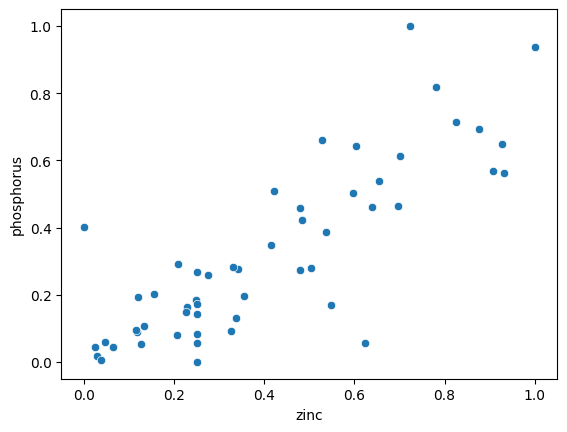

In [2]:
import seaborn as sns

sns.scatterplot(data=data, x='zinc', y='phosphorus');

❓ İki `np.Array` oluşturun
- çinko için `data_X` 
- fosfor için `data_Y`

In [6]:
import numpy as np

data_X = np.array(data['zinc'])
data_Y = np.array(data['phosphorus'])

print(data_X.shape, data_Y.shape)

(53,) (53,)


In [7]:
assert (data_X.shape == (53,))
assert (data_Y.shape == (53,))

## 2. Bir Epoch Kodlama

Bu egzersizin bu bölümünde, gradyan inişinin bir epoch $\color {red}{(k)}$ sırasında parametreleri güncellemek için kullanılan temel fonksiyonları tanımlayacaksınız. Aşağıdaki formülü hatırlayın

$$
\beta_0^{\color {red}{(k+1)}} = \beta_0^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_0}(\beta^{\color{red}{(k)}})
$$


$$
\beta_1^{\color {red}{(k+1)}} = \beta_1^{\color {red}{(k)}} - \eta \frac{\partial L}{\partial \beta_1}(\beta^{\color {red}{(k)}})
$$

### 2.1 Hipotez Fonksiyonu

$$
\hat{y} =  a x + b
$$

❓ Doğrusal Regresyon hipotez fonksiyonunu tanımlayın. `a`'nın eğim ve `b`'nin y-kesiti olmasına izin verin.

In [47]:
def h(X,a,b):
    y_pred = a*X + b
    return y_pred

### 2.2 Kayıp Fonksiyonu

$$
Kareler\ Toplamı\ Kaybı = \sum_{i=0}^n (y^{(i)} - \hat{y}^{(i)} )^2
$$

❓ Yukarıdaki denklemi kullanarak Hipotez Fonksiyonu için SSR Kayıp Fonksiyonunu tanımlayın. Yeni fonksiyonunuzu yazarken yukarıda kodlanan `h` fonksiyonunu yeniden kullanın.

In [10]:
import numpy as np

def loss(X,Y,a,b):
    y_pred = h(X,a,b)
    loss = np.sum((Y - y_pred)**2)
    return loss

❓ Eğer aşağıdaki değerler olsaydı tüm malzemeler veri setimizde hesaplanan toplam Kayıp ne olurdu:
- a = 1 
- b = 1

In [11]:
loss(data_X, data_Y, 1, 1)

63.868506986115456

⚠️ 63.86 değerini alıyor olmalısınız. Eğer almıyorsanız, fonksiyonunuzda bir şeyler yanlış. Devam etmeden önce düzeltin!

### 2.3 Gradyan

$$
\frac{d\ SSR}{d\ eğim}= \sum_{i=0}^n -2  x_i (y^{(i)} - \hat{y}^{(i)} )
$$

$$
\frac{d\ SSR}{d\ y-kesiti}= \sum_{i=0}^n -2(y^{(i)} - \hat{y}^{(i)} ) 
$$

❓ Belirli bir noktada `a` ve `b` parametrelerine göre Kayıp Fonksiyonunun kısmi türevlerini hesaplayan bir fonksiyon tanımlayın.

<details>
<summary>💡 İpucu</summary>
Yine, verilen noktalarda tahminleri hesaplamak için yeni fonksiyonunuzda Hipotez Fonksiyonunu yeniden kullanmalısınız.
</details>

In [12]:
def gradient(X,Y,a,b):
    y_pred = h(X,a,b)
    d_a = -2 * np.sum(X * (Y - y_pred))
    d_b = -2 * np.sum(Y - y_pred)
    return d_a, d_b

❓ Fonksiyonunuzu kullanarak, eğer aşağıdaki değerler olsaydı her parametrenin kısmi türevleri ne olurdu:
- a = 1
- b = 1

In [13]:
gradient(data_X, data_Y, 1, 1)

(48.459065809109006, 115.17923733301406)

⚠️ 48.45 ve 115.17 değerlerini alıyor olmalısınız. Eğer almıyorsanız, fonksiyonunuzu düzeltin!

### 2.4 Adım Boyutları

$$
adım\ boyutu = gradyan \cdot öğrenme\ oranı
$$

❓ Her parametre (`a`,`b`) boyunca, türevleri (`d_a`, `d_b`) ve varsayılan olarak `0.01`'e eşit bir `learning_rate`'e göre adım boyutlarını hesaplayan bir fonksiyon tanımlayın

In [21]:
def steps(d_a,d_b, learning_rate = 0.01):
    step_a = learning_rate * d_a
    step_b = learning_rate * d_b
    return (step_a, step_b)

❓ (`a`,`b`) = (1,1) için yukarıda hesaplanan türevler için atılacak adımlar (`step_a`, `step_b`) ne olurdu?

In [17]:
steps(gradient(data_X, data_Y, 1, 1)[0], gradient(data_X, data_Y, 1, 1)[1], learning_rate = 0.01)

(0.4845906580910901, 1.1517923733301405)

⚠️ Adımlar `a` için 0.48 ve `b` için 1.15 olmalıdır

### 2.5 Parametreleri güncellemek (a, b)

$$
güncellenmiş\ parametre = eski\ parametre\ değeri - adım\ boyutu
$$

❓ Eski parametre değerlerinden ve adım boyutlarından güncellenmiş parametre değerlerini hesaplayan bir fonksiyon tanımlayın.

In [18]:
def update_params(a, b, step_a, step_b):
    a_new = a - step_a
    b_new = b - step_b
    return a_new , b_new

### 2.6 Tam bir epoch

❓ Az önce oluşturduğunuz fonksiyonları kullanarak, aşağıdaki parametrelerle başlamış olsaydınız ilk Epoch'un sonunda güncellenmiş parametreleri hesaplayın:
- a = 1
- b = 1

In [20]:
update_params(1, 1, steps(gradient(data_X, data_Y, 1, 1)[0], gradient(data_X, data_Y, 1, 1)[1], learning_rate = 0.01)[0], steps(gradient(data_X, data_Y, 1, 1)[0], gradient(data_X, data_Y, 1, 1)[1], learning_rate = 0.01)[1])


(0.5154093419089099, -0.1517923733301405)

⚠️ Aşağıdaki değerleri alıyor olmalısınız:
   - updated_a = 0.51
   - updated_b = -0.15

## 3. Gradyan İnişi

❓ Artık Gradyan İnişi için gerekli fonksiyonlara sahip olduğunuza göre, yakınsama sağlanana kadar epoch'lar boyunca döngü yapın.

- `a = 1` ve `b = 1` parametrelerini başlatın
- Yakınsamayı **100 epoch** olarak kabul edin
- Her yeni epoch'u güncellenmiş parametrelerle başlatmayı unutmayın
- Her epoch'ta `loss`, `a`, ve `b` değerlerini sırasıyla `loss_history`, `a_history` ve `b_history` adlı listelerine ekleyin

In [ ]:
gradient_history = gradient(data_X, data_Y, 1, 1)
steps_history = steps(gradient_history[0], gradient_history[1], learning_rate=0.01)
update_params_history = update_params(1, 1, steps_history[0], steps_history[1])

print(f"a_1 = {update_params_history[0]}, b_1 = {update_params_history[1]}")

a_1 = 0.5154093419089099, b_1 = -0.1517923733301405


❓ 100 epoch'un sonundaki parametre değerleri nelerdir? Onları sırasıyla `a_100` ve `b_100` değişkenlerine kaydedin

In [ ]:
a, b = 1, 1
loss_history, a_history, b_history = [], [], []

for i in range(100):
    gradient_history = gradient(data_X, data_Y, a, b)
    steps_history = steps(gradient_history[0], gradient_history[1], learning_rate=0.01)
    update_params_history = update_params(a, b, steps_history[0], steps_history[1])

    a, b = update_params_history[0], update_params_history[1]

    current_loss= loss(data_X, data_Y, a, b)
    loss_history.append(current_loss)
    a_history.append(a)
    b_history.append(b)

a_100, b_100 = a_history[-1], b_history[-1]
print(f"Final parameters: a_100 = {a_100}, b_100 = {b_100}")

Final parameters: a_100 = 0.768671510620374, b_100 = 0.00708932115622393


In [33]:
# 🧪 Test your code
from nbresult import ChallengeResult
result = ChallengeResult('descent',
                         a_100=a_100,
                         b_100=b_100)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/didemarslan/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/didemarslan/reading_the_green_line/S16D1-S-data-knn/S16D3-S-data-electrocardiograms/S16D3-S-data-threshold/S16D4-S-loss-functions/S16D4-S-data-solvers/S16D4-S-gradient-descent/tests
plugins: dash-4.4.1, langsmith-0.12.4, typeguard-4.4.2, anyio-4.15.1
collecting ... collected 2 items

test_descent.py::TestDescent::test_a PASSED                              [ 50%]
test_descent.py::TestDescent::test_b PASSED                              [100%]

============================== 2 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/descent.pickle

git commit -m 'Completed descent step'

git push origin master



## 4. Görsel kontrol

❓ Bu yinelemeli yaklaşımı `gradient_descent()` metoduna sarın, bu metod `new_a`, `new_b` ve şu listeleri içeren bir sözlük olan `history`'yi döndürsün: 
- `loss_history`
- `a_history`
- `b_history`

In [34]:
def gradient_descent(X, Y, a_init=1, b_init=1, learning_rate=0.001, n_epochs=100):
    a, b = a_init, b_init
    loss_history, a_history, b_history = [], [], []

    for i in range(n_epochs):
        gradient_history = gradient(X, Y, a, b)
        steps_history = steps(gradient_history[0], gradient_history[1], learning_rate=learning_rate)
        update_params_history = update_params(a, b, steps_history[0], steps_history[1])

        a, b = update_params_history[0], update_params_history[1]

        current_loss = loss(X, Y, a, b)
        loss_history.append(current_loss)
        a_history.append(a)
        b_history.append(b)

    history = {
        'loss_history': loss_history,
        'a_history': a_history,
        'b_history': b_history
    }
    return a, b, history

In [52]:
final_a, final_b, history = gradient_descent(data_X, data_Y, a_init=1, b_init=1, learning_rate=0.01, n_epochs=1000)
print(f"Final parameters from gradient_descent function: a = {final_a}, b = {final_b}")
print(f"Final loss from gradient_descent function: loss = {history['loss_history'][-1]}")

Final parameters from gradient_descent function: a = 0.7688371715345799, b = 0.00701772020106239
Final loss from gradient_descent function: loss = 1.082068791283076


❓ Gradyan İniş'inizin parametrelerini kullanarak Çinko ve Fosfor arasında en uygun çizgiyi çizin.

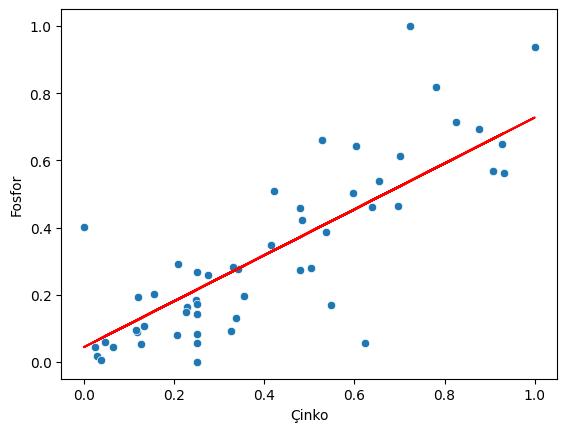

In [38]:
import matplotlib.pyplot as plt

y_pred = h(data_X, final_a, final_b)

sns.scatterplot(x=data_X, y=data_Y)
plt.plot(data_X, y_pred, color='red')
plt.xlabel('Çinko')
plt.ylabel('Fosfor')
plt.show()

## 5. İnişinizi görselleştirin

🎯 Hedefimiz kayıp fonksiyonumuzu ve gradyan inişi adımlarını matplotlib'in `contourf` kullanarak 2D yüzey üzerinde çizmektir

❓ Çizim için ihtiyacımız olan veriyi oluşturarak başlayın
- `range_a`: `a` için -1 ile 1 arasında eşit aralıklı 100 değerlik bir aralık
- `range_b`: `b` için -1 ile 1 arasında eşit aralıklı 100 değerlik bir aralık 
- `Z`: her `Z[j,i]` elementinin `a` = `range_a[i]` ve `b` = `range_b[j]` noktasında kayıp fonksiyonunun değerine eşit olduğu 2D-dizi

In [39]:
range_a = np.linspace(-1, 1, 100)
range_b = np.linspace(-1, 1, 100)
Z = np.zeros((100, 100))

for i in range(100):
    for j in range(100):
        Z[j, i] = loss(data_X, data_Y, range_a[i], range_b[j])

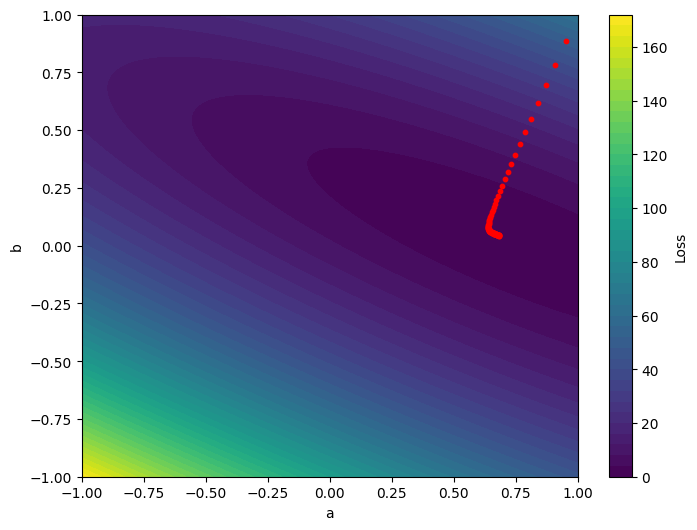

In [40]:
plt.figure(figsize=(8,6))
plt.contourf(range_a, range_b, Z, levels=50, cmap='viridis')
plt.colorbar(label='Loss')
plt.scatter(history['a_history'], history['b_history'], color='red', s=10)
plt.xlabel('a')
plt.ylabel('b')
plt.show()

❓ Şimdi, tek bir subplot'ta şunları çizin:
- 3 parametre ile matplotlib [contourf](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.contourf.html) kullanarak kayıp fonksiyonunuzu 2D-yüzey olarak
- gradyan inişinizi görselleştirmek için tüm geçmiş (a,b) noktalarını kırmızı noktalar olarak serpilme grafiği!

Öğrenme oranınızı değiştirin ve grafik üzerindeki etkisini gözlemleyin!

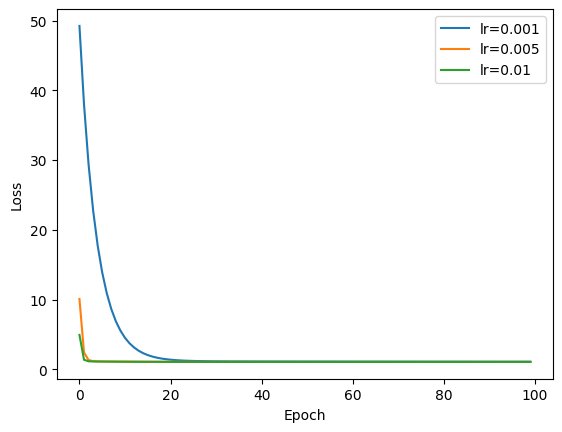

In [48]:
for lr in [0.001, 0.005, 0.01]:
    _, _, hist = gradient_descent(data_X, data_Y, learning_rate=lr, n_epochs=100)
    plt.plot(hist['loss_history'], label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

❓ [isteğe bağlı] Peki ya 3D? Aşağıda aynı veriyi [plot.ly 3D kontur grafiği](https://plotly.com/python/3d-surface-plots/) üzerinde çizmeyi deneyin

In [51]:
import plotly.graph_objects as go

surface = go.Surface(x=range_a, y=range_b, z=Z)
scatter = go.Scatter3d(x=history['a_history'], y=history['b_history'], z=history['loss_history'], mode='markers')
fig = go.Figure(data=[surface, scatter])

#fig.update_layout(title='Loss Function', autosize=False, width=500, height=500)
fig.show()

❓ `kayıp` değerlerinin geçmişini `epoch` sayısının bir fonksiyonu olarak çizin. 0.001'den 0.01'e kadar `learning_rate`'in birden fazla varyasyonuyla deneyin ve farkı anladığınızdan emin olun

## 6. Sklearn ile...

❓ Sklearn kullanarak, aynı veri üzerinde bir Doğrusal Regresyon modeli eğitin. Parametrelerini Gradyan İnişiniz ile hesaplananlarla karşılaştırın.

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(data_X.reshape(-1,1), data_Y)
print(f"sklearn: a={model.coef_[0]:.4f}, b={model.intercept_:.4f}")
print(f"gradient descent: a={final_a:.4f}, b={final_b:.4f}")

sklearn: a=0.7688, b=0.0070
gradient descent: a=0.7688, b=0.0070


Hemen hemen aynı olmalıdırlar!

### 🏁 Tebrikler! İşiniz bittiğinde lütfen egzersizinizi push edin